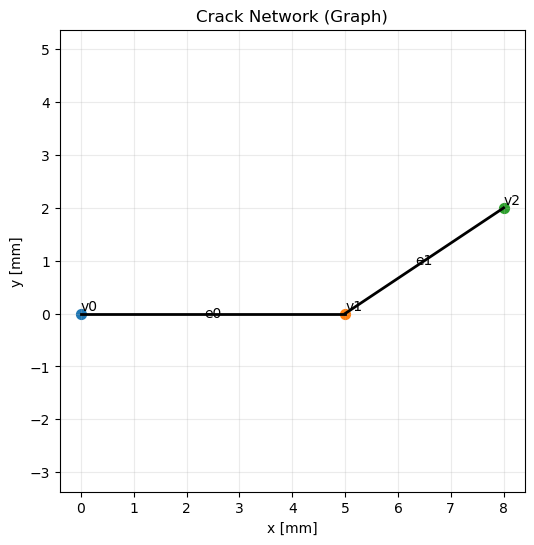

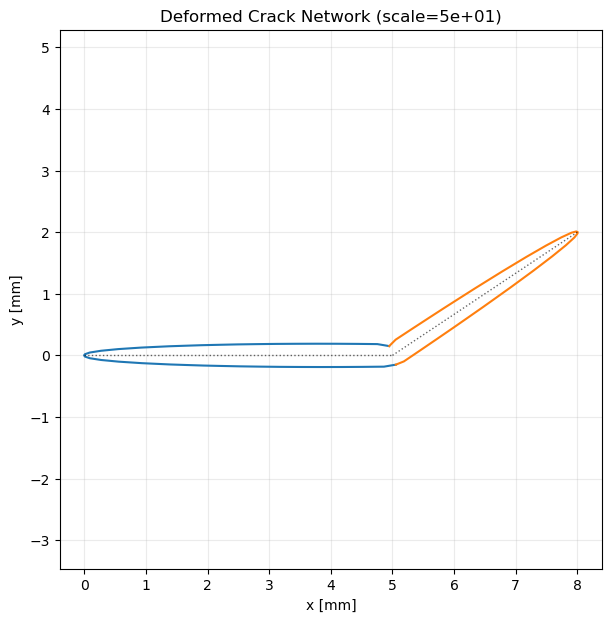

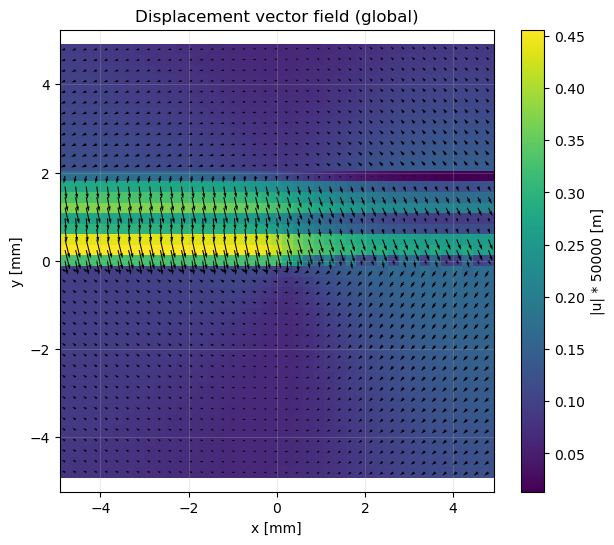

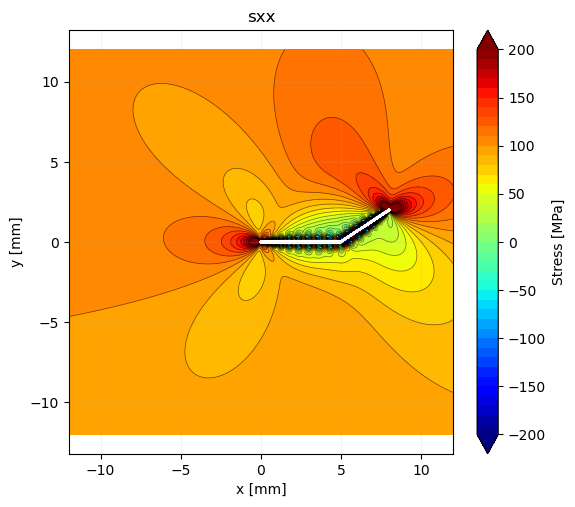

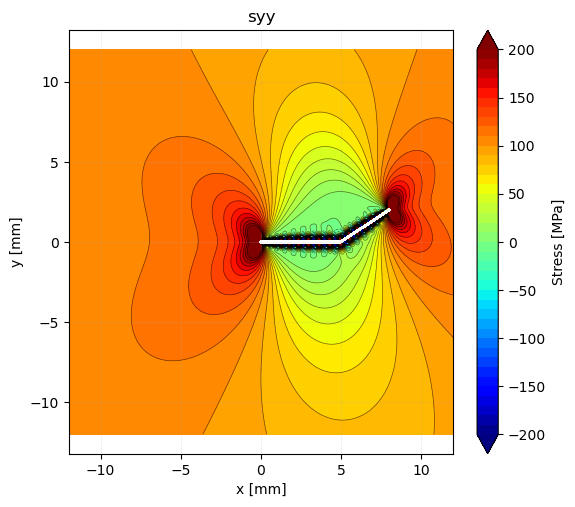

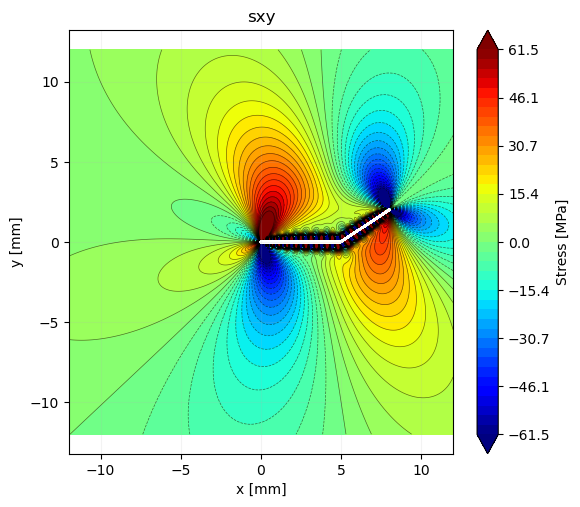

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# --- Ensure repo root on sys.path (so "utils" is importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils
utils.reload_all()
from utils import *
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1")
out_dir.mkdir(parents=True, exist_ok=True)


# -------------------------
# Define Y network: vertices + connectivity
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 junction
    [1,   5.0*mm,  0*mm], # v1 upper-right
    [2,   8.0*mm, 2.0*mm], # v2 lower-right
], dtype=float)

# edges: (edge_id, v0, v1)
connectivity = np.array([
    [0, 1],
    [1, 2],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)

# -------------------------
# Solve
# -------------------------
sol = calc.solve(
    ne_half=20,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,   # OK to keep; ignored by the delegated single-crack solve
    n_int=96,
)

res = DCEResultsNetworkV4(calc, sol)
plotter = DCEPlotterV4(res, out_dir=out_dir)

# Graph topology
plotter.plot_network_graph()

# Deformed crack network
plotter.plot_deformed_network(scale=5e1, n_pts_per_edge=800, 
                              show_faces=True, cod_smooth_window=5)

# Displacement vector field
plotter.plot_displacement_vector_field(
    extent_factor=1.2,
    n_grid=41,
    scale=1.0,
    disp_scale=5e4,
    mask_cracks=False,
)

# Stress fields (global)
opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=400,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


edge 0: pid 0 meets kink at start,  J(kink) = [-7.73124872e-06  9.90200096e-06]
edge 1: pid 1 meets kink at start,  J(kink) = [-7.73124872e-06  9.90200096e-06]


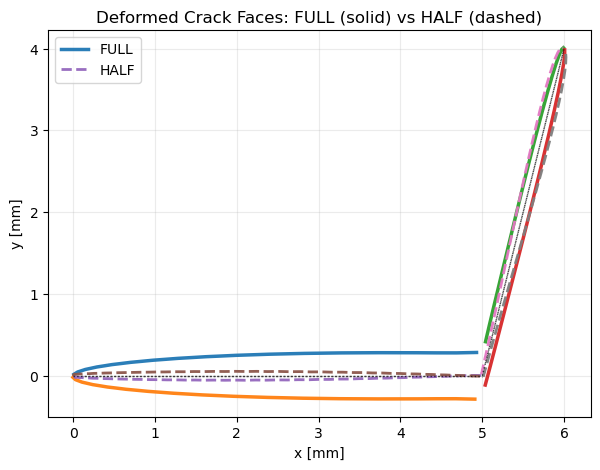

Comparison complete. Output dir: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1_half_compare


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys, importlib

# --- Ensure repo root on sys.path (so "utils" and "utils_half" are importable)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

# -------------------------
# Imports: full vs half packages
# -------------------------
import utils
utils.reload_all()
from utils import (
    CrackNetworkV4, Material, AppliedStress, DCENetworkStaticV4, DCEResultsNetworkV4
)

import utils_half
# If your utils_half has reload_all(), use it; otherwise skip safely.
if hasattr(utils_half, "reload_all") and callable(utils_half.reload_all):
    utils_half.reload_all()
from utils_half import (
    DCENetworkStaticV4 as DCENetworkStaticV4_half,
    DCEResultsNetworkV4 as DCEResultsNetworkV4_half,
)

# -------------------------
# Output directory
# -------------------------
out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\network-1_half_compare")
out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------
# Define kinked 2-segment network (same as your full-crack run)
# Units: meters
# -------------------------
mm = 1e-3
vertices = np.array([
    [0,   0.0*mm,  0.0*mm],   # v0 left tip
    [1,   5.0*mm,  0.0*mm],   # v1 kink (degree-2 vertex)
    [2,   6.0*mm,  4.0*mm],   # v2 right tip
], dtype=float)

connectivity = np.array([
    [0, 1],
    [1, 2],
], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(
    vertices=vertices,
    connectivity=connectivity,
    Nv_max=3,
    validate=True,
)

material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

# -------------------------
# Solve: FULL crack (current utils)
# -------------------------
calc_full = DCENetworkStaticV4(material, net, applied)

sol_full = calc_full.solve(
    ne_half=30,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    n_int=96,
)

res_full = DCEResultsNetworkV4(calc_full, sol_full)

# -------------------------
# Solve: HALF crack formulation (utils_half)
# -------------------------
calc_half = DCENetworkStaticV4_half(material, net, applied)

# NOTE: This assumes your new solver adds an *additional* option for half cracks.
# Common patterns:
#   - crack_mode="half"
#   - or solver_option="half_crack"
#   - or junction_option=... with crack_mode inferred
#
# Update the keyword below to match your utils_half API.
sol_half = calc_half.solve(
    ne_half=30,
    representation="cheb_quad",
    node_distribution="tip_dense",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",   # <--- CHANGE THIS if your API uses a different flag
)

res_half = DCEResultsNetworkV4_half(calc_half, sol_half)

# -------------------------
# Helper: pull deformed crack faces per edge (midpoint reconstruction)
# and plot both solutions overlaid for direct comparison.
# -------------------------
def plot_faces(ax, res, edge_indices, *, scale=5e2, ls="-", lw=2.0, alpha=1.0, label_prefix=""):
    for ei in edge_indices:
        xyU, xyL, extra = res.crack_face_coords_panel_midpoints(
            ei, scale=scale, enforce_global_tip_zero=True
        )
        # plot upper/lower faces
        ax.plot(xyU[:,0]/mm, xyU[:,1]/mm, ls=ls, lw=lw, alpha=alpha, label=f"{label_prefix} edge {ei} U")
        ax.plot(xyL[:,0]/mm, xyL[:,1]/mm, ls=ls, lw=lw, alpha=alpha, label=f"{label_prefix} edge {ei} L")

        # plot the undeformed centerline (dotted)
        # midpoints are in extra["xy_mid"] for this edge
        xy_mid = np.asarray(extra["xy_mid"], float)
        ax.plot(xy_mid[:,0]/mm, xy_mid[:,1]/mm, "k:", lw=1.0, alpha=0.7)
        
def plot_faces_half(ax, res, edge_indices, *, scale=5e2, ls="-", lw=2.0, alpha=1.0, label_prefix=""):
    for ei in edge_indices:
        xyU, xyL, extra = res.crack_face_coords_panel_midpoints(
            ei, scale=scale, enforce_global_tip_zero=True
        )
        # plot upper/lower faces
        ax.plot(xyU[:,0]/mm, xyU[:,1]/mm, ls=ls, lw=lw, alpha=alpha, label=f"{label_prefix} edge {ei} U")
        ax.plot(xyL[:,0]/mm, xyL[:,1]/mm, ls=ls, lw=lw, alpha=alpha, label=f"{label_prefix} edge {ei} L")

        # plot the undeformed centerline (dotted)
        # midpoints are in extra["xy_mid"] for this edge
        xy_mid = np.asarray(extra["xy_mid"], float)
        ax.plot(xy_mid[:,0]/mm, xy_mid[:,1]/mm, "k:", lw=1.0, alpha=0.7)
# kink vertex id in your example is v=1
vk = 1

# map each edge -> (pid, which end) and report J at that vertex
e2p = sol_half["parametrized_edge_to_polyline"]
polys = sol_half["parametrized_polylines"]
solps = sol_half["polyline_solutions"]

def J_at_poly_end(pid, which):
    s = solps[pid]
    bI  = np.asarray(s["bI"], float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"], float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)

    J0 = np.asarray(s.get("J0", [0.0, 0.0]), float)
    J = J0.copy()
    if which == "end":
        for k in range(len(ds)):
            J += -(bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return J

for ei in [0, 1]:
    pid = int(e2p[ei])
    pmeta = polys[pid]
    v_start = int(pmeta.get("v_start", pmeta["path_vertex_ids"][0]))
    v_end   = int(pmeta.get("v_end",   pmeta["path_vertex_ids"][-1]))

    if vk == v_start:
        which = "start"
    elif vk == v_end:
        which = "end"
    else:
        which = "none"

    if which != "none":
        Jv = J_at_poly_end(pid, which)
        print(f"edge {ei}: pid {pid} meets kink at {which},  J(kink) = {Jv}")
    else:
        print(f"edge {ei}: pid {pid} does NOT meet kink?? (start={v_start}, end={v_end})")

# -------------------------
# Plot overlay: FULL vs HALF
# -------------------------
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

edge_indices = [0, 1]

# Full crack (solid)
plot_faces(ax, res_full, edge_indices, scale=9e1, ls="-", lw=2.5, alpha=0.95, label_prefix="FULL")

# Half crack (dashed)
plot_faces_half(ax, res_half, edge_indices, scale=9e1, ls="--", lw=2.0, alpha=0.95, label_prefix="HALF")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x [mm]")
ax.set_ylabel("y [mm]")
ax.set_title("Deformed Crack Faces: FULL (solid) vs HALF (dashed)")

# Reduce legend clutter: show only one entry per category
handles, labels = ax.get_legend_handles_labels()
keep = []
seen = set()
for h, lab in zip(handles, labels):
    key = ("FULL" if lab.startswith("FULL") else "HALF")
    if key not in seen:
        keep.append((h, key))
        seen.add(key)
ax.legend([h for h,_ in keep], [lab for _,lab in keep], loc="best")

ax.grid(True, alpha=0.25)
plt.show()

print("Comparison complete. Output dir:", out_dir)


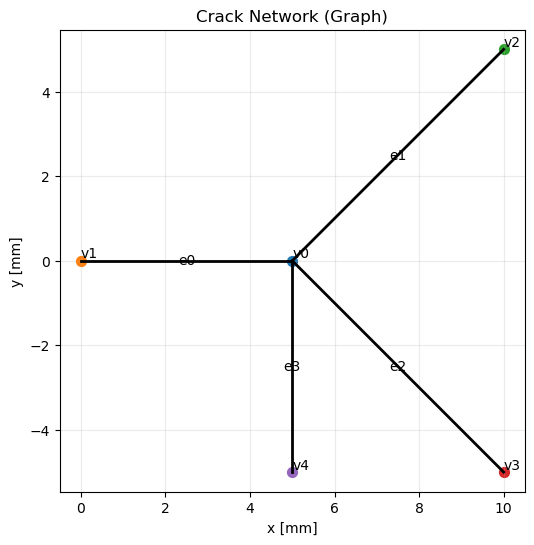

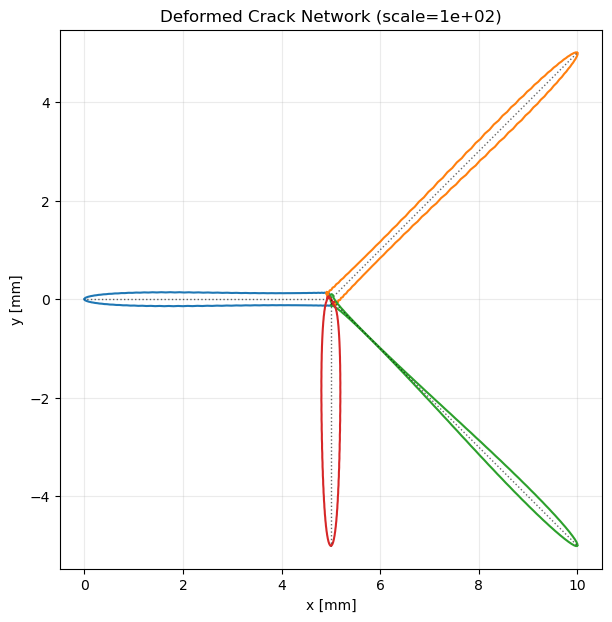

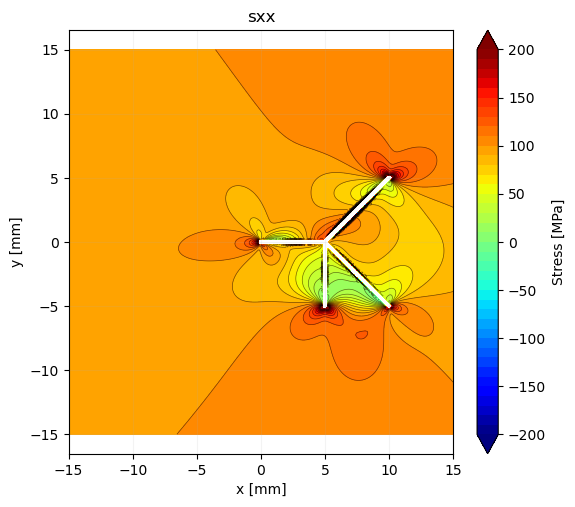

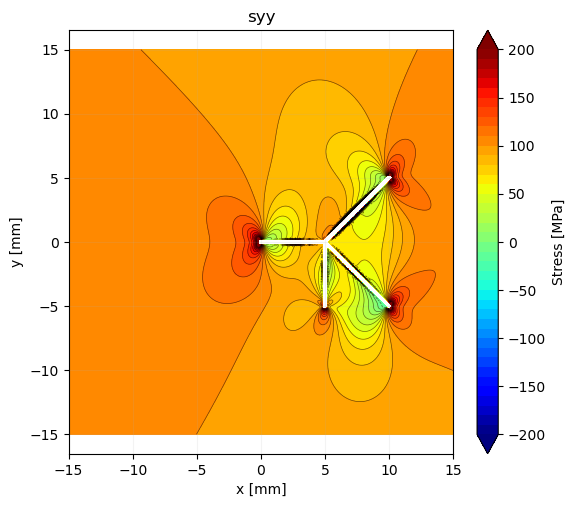

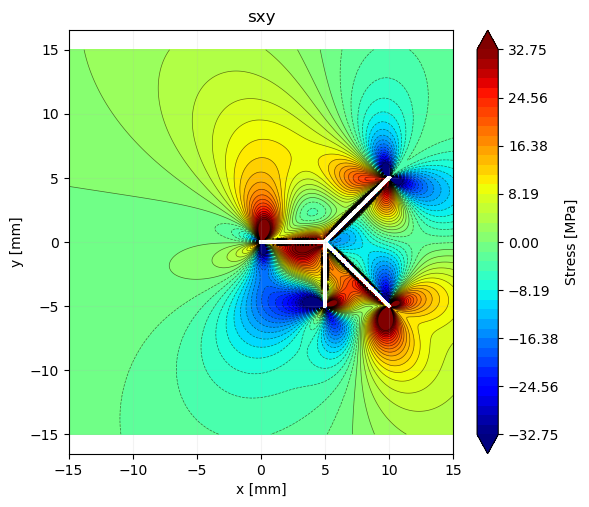

Saved figures to: C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half

=== JUNCTION CONSTRAINT DIAGNOSTICS (HALF CRACK, Option A) ===

--- Vertex v=0 (degree=4) ---
Incident branches (pid, end): [(0, 'start'), (1, 'start'), (2, 'start'), (3, 'start')]
  pid  0  J(v) = [3.83990234e-19 4.07030404e-19]
  pid  1  J(v) = [3.83990234e-19 4.07030404e-19]
  pid  2  J(v) = [3.83990234e-19 4.07030404e-19]
  pid  3  J(v) = [3.83990234e-19 4.07030404e-19]
  |J[1] - J[0]| = 0.000e+00
  |J[2] - J[0]| = 0.000e+00
  |J[3] - J[0]| = 0.000e+00
  pid  0  B = [-9.18382238e-19 -3.25144185e-18]
  pid  1  B = [-8.83561243e-19  4.95884851e-19]
  pid  2  B = [-6.42606839e-19 -3.10516985e-18]
  pid  3  B = [4.81273533e-19 2.39085637e-18]
  Sum B = [-1.96327679e-18 -3.46987047e-18]  |norm| = 3.9867852730937945e-18
  Projection direction p = [0.92387953 0.38268343]
  p · Sum B = -3.1416931817593423e-18
pid 0: v_start=0 (deg=4), v_end=1 (deg=1)
   J(start)=[3.83990234e-19 4.07030404e-19

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys

nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils_half
utils_half.reload_all()

from utils import CrackNetworkV4, Material, AppliedStress
from utils_half import DCENetworkStaticV4, DCEResultsNetworkV4
from utils_half.plotter import DCEPlotterV4, StressPlotOptsV4  # adjust if your facade exports these

mm = 1e-3
vertices = np.array([
    [0,  5.0*mm,  0.0*mm],   # junction
    [1,  0.0*mm,  0.0*mm],   # left tip
    [2, 10.0*mm,  5.0*mm],   # upper tip
    [3, 10.0*mm, -5.0*mm],   # lower tip
    [4, 5.0*mm, -5.0*mm]
], dtype=float)

connectivity = np.array([[0,1],[0,2],[0,3],[0,4]], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(vertices=vertices, connectivity=connectivity, Nv_max=4, validate=True)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=100e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
)

res = DCEResultsNetworkV4(calc, sol)

out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

plotter = DCEPlotterV4(res, out_dir=out_dir)

plotter.plot_network_graph()
plotter.plot_deformed_network(scale=1e2, n_pts_per_edge=2000, show_faces=True, cod_smooth_window=5)

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)


print("\n=== JUNCTION CONSTRAINT DIAGNOSTICS (HALF CRACK, Option A) ===")

# ---- convenience handles from solution dict ----
e2p    = sol["parametrized_edge_to_polyline"]
polys  = sol["parametrized_polylines"]
solps  = sol["polyline_solutions"]

# ---- compute vertex degrees from edges (no VertexV4.degree needed) ----
deg = {int(v.id): 0 for v in calc.network.vertices}
for e in calc.network.edges:
    deg[int(e.v0)] = deg.get(int(e.v0), 0) + 1
    deg[int(e.v1)] = deg.get(int(e.v1), 0) + 1

# ---- build vertex -> incident (pid, which_end) map ----
v_inc = {}
for ei, pid in e2p.items():
    pid = int(pid)
    pmeta = polys[pid]
    v0 = int(pmeta.get("v_start", pmeta["path_vertex_ids"][0]))
    v1 = int(pmeta.get("v_end",   pmeta["path_vertex_ids"][-1]))
    v_inc.setdefault(v0, []).append((pid, "start"))
    v_inc.setdefault(v1, []).append((pid, "end"))

# ---- helpers ----
def outgoing_tangent(pid, which):
    s = solps[pid]
    t = np.asarray(s.get("t_mid", s.get("t_col")), float)
    if which == "start":
        return +t[0]
    else:
        return -t[-1]

def B_of_branch(pid):
    s = solps[pid]
    bI  = np.asarray(s["bI"],  float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"],  float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)

    B = np.zeros(2)
    for k in range(len(ds)):
        B += (bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return B

def J_at_vertex(pid, which):
    s = solps[pid]
    bI  = np.asarray(s["bI"],  float)
    bII = np.asarray(s["bII"], float)
    ds  = np.asarray(s["ds"],  float)
    t   = np.asarray(s.get("t_mid", s.get("t_col")), float)
    n   = np.asarray(s.get("n_mid", s.get("n_col")), float)

    J0 = np.asarray(s.get("J0", [0.0, 0.0]), float)
    J = J0.copy()

    if which == "end":
        for k in range(len(ds)):
            J -= (bII[k]*t[k] + bI[k]*n[k]) * ds[k]
    return J

# ---- diagnostics per junction ----
for v, items in v_inc.items():
    dv = deg.get(int(v), 0)
    if dv < 2:
        continue

    print(f"\n--- Vertex v={v} (degree={dv}) ---")
    print("Incident branches (pid, end):", items)

    # J continuity
    Js = []
    for (pid, which) in items:
        Jv = J_at_vertex(pid, which)
        Js.append(Jv)
        print(f"  pid {pid:2d}  J(v) = {Jv}")

    J_ref = Js[0]
    for j, Jv in enumerate(Js[1:], start=1):
        print(f"  |J[{j}] - J[0]| = {np.linalg.norm(Jv - J_ref):.3e}")

    # Burgers content
    Bs = []
    for (pid, _) in items:
        Bj = B_of_branch(pid)
        Bs.append(Bj)
        print(f"  pid {pid:2d}  B = {Bj}")

    Bsum = np.sum(Bs, axis=0)
    print("  Sum B =", Bsum, " |norm| =", np.linalg.norm(Bsum))

    # Option B projected neutrality check (only for dv >= 3)
    if dv >= 3:
        g = np.zeros(2)
        for (pid, which) in items:
            g += outgoing_tangent(pid, which)

        ng = np.linalg.norm(g)
        if ng > 0:
            g /= ng
            proj = np.array([-g[1], g[0]])
            r = float(proj @ Bsum)
            print("  Projection direction p =", proj)
            print("  p · Sum B =", r)
        else:
            print("  WARNING: could not form projection direction (ng=0)")
            
            print("\n--- Tip jump check (Option A sanity) ---")
for pid, meta in enumerate(sol["parametrized_polylines"]):
    vids = meta["path_vertex_ids"]
    v_start, v_end = int(vids[0]), int(vids[-1])
    # start is junction end, end is tip end in your convention
    J_start = J_at_vertex(pid, "start")
    J_end   = J_at_vertex(pid, "end")
    print(f"pid {pid}: v_start={v_start} (deg={deg[v_start]}), v_end={v_end} (deg={deg[v_end]})")
    print(f"   J(start)={J_start},  J(end/tip)={J_end}")


print("\n=== END JUNCTION DIAGNOSTICS ===")


# common J at the junction from your diagnostic (or recompute from solps)
Jv = np.array([-1.14324090e-06, -1.02223602e-05])  # example

# outgoing unit tangents at junction (use your diagnostic helper)
def unit(v):
    n = np.linalg.norm(v)
    return v/n if n>0 else v

for (pid, which) in [(0,"start"), (1,"start"), (2,"start")]:
    t = outgoing_tangent(pid, which)          # from your diagnostic snippet
    t = unit(t)
    n = np.array([-t[1], t[0]])               # CCW normal
    COD = float(Jv @ n)
    CSD = float(Jv @ t)
    print(f"pid {pid}: COD(v0)={COD:.3e}  CSD(v0)={CSD:.3e}")
    
import numpy as np

def tip_jump_from_reconstruction(res, edge_index):
    x, COD, CSD, extra = res.reconstruct_cod_csd_panel_midpoints(
        edge_index=edge_index,
        enforce_global_tip_zero=True,
    )
    ex = np.asarray(extra["ex"], float)
    ey = np.asarray(extra["ey"], float)

    COD_tip = float(COD[-1])
    CSD_tip = float(CSD[-1])

    J_tip = ex * CSD_tip + ey * COD_tip
    return COD_tip, CSD_tip, J_tip

for ei in [0, 1, 2]:
    COD_tip, CSD_tip, J_tip = tip_jump_from_reconstruction(res, ei)
    print(f"edge {ei}: COD_tip={COD_tip:+.3e}  CSD_tip={CSD_tip:+.3e}  J_tip={J_tip}")




In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os, sys

nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

import utils_half
utils_half.reload_all()

from utils import CrackNetworkV4, Material, AppliedStress
from utils_half import DCENetworkStaticV4, DCEResultsNetworkV4
from utils_half.plotter import DCEPlotterV4, StressPlotOptsV4  # adjust if your facade exports these

mm = 1e-3
vertices = np.array([
    [0, 0.0*mm, -8.0*mm], 
    [1,  0.0*mm,  0.0*mm],   
    [2,  5.0*mm,  5.0*mm],   
    [3, -5.0*mm,  5.0*mm],   
    [4, 8.0*mm, 5.0*mm],
    [5, 0.0*mm, 8.0*mm],
    [6, -8.0*mm, 5.0*mm],
    [7, 0.0*mm, 8.0*mm],  
    [8,  0.0*mm,  -1.0*mm],   

], dtype=float)

connectivity = np.array([[0,8],[1,2],[1,3],[2,4],[2,5],[3,6],[3,7]], dtype=int)

net = CrackNetworkV4.from_vertices_connectivity(vertices=vertices, connectivity=connectivity, Nv_max=4, validate=True)
material = Material(E=200e9, nu=0.30, plane_stress=False)
applied  = AppliedStress(sigma_xx=0e6, sigma_yy=100e6, sigma_xy=0.0)

calc = DCENetworkStaticV4(material, net, applied)
sol  = calc.solve(
    ne_half=40,
    representation="cheb_quad",
    node_distribution="uniform",
    solver_option="parametrized_crack",
    parametrization="polyline",
    nq_col=3,
    nq_stress=6,
    crack_mode="half",
)

res = DCEResultsNetworkV4(calc, sol)

out_dir = Path(r"C:\Users\Owner\Documents\Repos\Fracture\VariationalCracks\output\Yjunction_half")
out_dir.mkdir(parents=True, exist_ok=True)

plotter = DCEPlotterV4(res, out_dir=out_dir)

plotter.plot_network_graph()
plotter.plot_deformed_network(scale=1e2, n_pts_per_edge=2000, show_faces=True, cod_smooth_window=5)

opts = StressPlotOptsV4(
    extent_factor=3,
    n_grid=301,
    add_remote=True,
    mask_cracks=True,
    cmap="jet",
    n_bands=40,
    label_contours=False,
    vmax_factor=2,
)
plotter.plot_stress_components_global(opts=opts, components=("sxx","syy","sxy"))

plt.show()
print("Saved figures to:", out_dir)




LinAlgError: Singular matrix